In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

In [2]:
df = pd.read_csv("credit_data.csv")
df.head()

,age,income,existing_debt,loan_amount,credit_history_years,num_late_payments,num_credit_lines,employment_years,debt_to_income,loan_to_income,default_risk
0,59,75795.13,21731.32,27062.01,16,1,10,9,0.287,0.357,0
1,49,44772.00,0.00,28002.47,21,1,14,17,0.000,0.625,0
2,35,52410.00,17521.67,15955.31,12,2,5,14,0.334,0.304,0
3,63,29426.51,3139.31,21655.00,11,1,13,32,0.107,0.736,0
4,28,24439.55,21084.42,26246.02,9,1,8,4,0.863,1.074,1


In [3]:
df.describe()

,age,income,existing_debt,loan_amount,credit_history_years,num_late_payments,num_credit_lines,employment_years,debt_to_income,loan_to_income,default_risk
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,42.694000,49623.611915,15242.886260,19819.870800,14.482000,1.498500,7.454500,19.781000,0.387082,0.499298,0.300000
std,12.614195,19240.405729,9335.364887,11715.506907,8.499694,1.255303,4.006614,11.571732,0.390084,0.473364,0.458372
min,21.000000,10000.000000,0.000000,1000.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.010000,0.000000
25%,32.000000,36073.950000,8275.520000,11170.465000,7.000000,1.000000,4.000000,10.000000,0.163000,0.216000,0.000000
50%,43.000000,49682.710000,14823.065000,19497.310000,15.000000,1.000000,8.000000,19.000000,0.300000,0.394000,0.000000
75%,54.000000,63064.310000,21623.690000,27862.155000,22.000000,2.000000,11.000000,30.000000,0.493250,0.625250,1.000000
max,64.000000,111238.940000,45147.120000,58881.670000,29.000000,8.000000,14.000000,39.000000,3.617000,4.699000,1.000000


In [4]:
print ("Размерность исходных данных: ", df.shape) 

Размерность исходных данных:  (2000, 11)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   2000 non-null   int64  
 1   income                2000 non-null   float64
 2   existing_debt         2000 non-null   float64
 3   loan_amount           2000 non-null   float64
 4   credit_history_years  2000 non-null   int64  
 5   num_late_payments     2000 non-null   int64  
 6   num_credit_lines      2000 non-null   int64  
 7   employment_years      2000 non-null   int64  
 8   debt_to_income        2000 non-null   float64
 9   loan_to_income        2000 non-null   float64
 10  default_risk          2000 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 172.0 KB


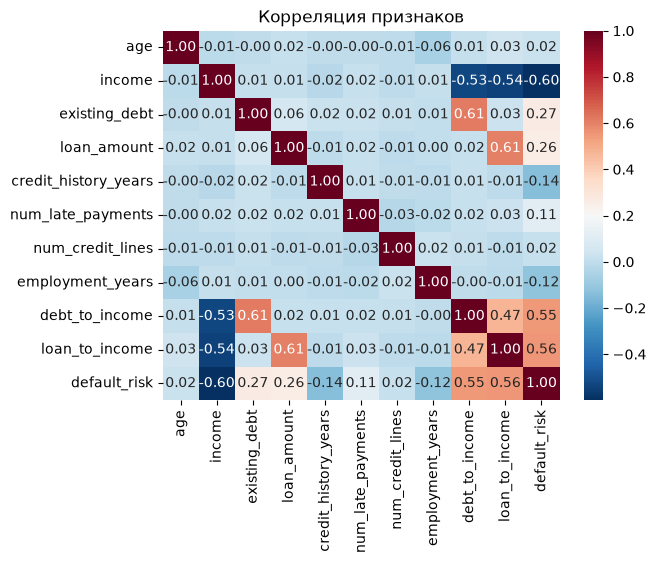

default_risk            1.000000
loan_to_income          0.555455
debt_to_income          0.546949
existing_debt           0.265603
loan_amount             0.258871
num_late_payments       0.111196
age                     0.020643
num_credit_lines        0.015880
employment_years       -0.122003
credit_history_years   -0.139853
income                 -0.599518
Name: default_risk, dtype: float64


In [6]:
corr_matrix = df.corr()
sns.heatmap(df.corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Корреляция признаков')
plt.show()

if "default_risk" in df.columns:
    corr_target = corr_matrix["default_risk"].sort_values(ascending=False)
    print(corr_target)

In [7]:
X = df.drop(columns=["default_risk"]) 
y = df["default_risk"]

X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
def train_and_evaluate(model, model_name, X_train, X_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    print(f"{model_name}\n")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Нет просрочки", "Просрочка"],
        yticklabels=["Нет просрочки", "Просрочка"]
    )
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Фактический класс")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": auc
    }

Logistic Regression

Accuracy : 0.9450
Precision: 0.9298
Recall   : 0.8833
F1-Score : 0.9060
ROC-AUC  : 0.9857


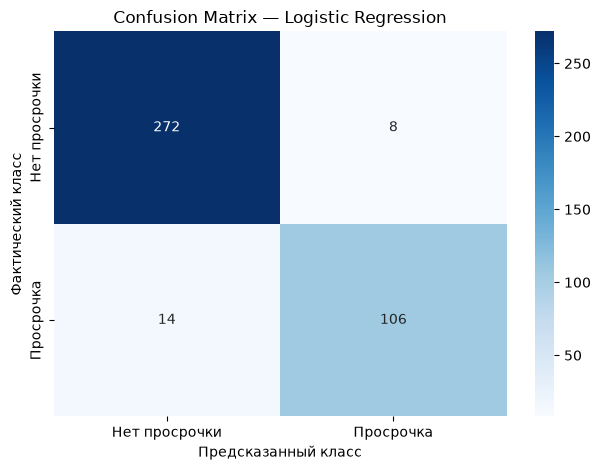

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_result = train_and_evaluate(
    logistic_model,
    "Logistic Regression",
    X_train_scaled,
    X_test_scaled
)

Decision Tree

Accuracy : 0.9000
Precision: 0.8390
Recall   : 0.8250
F1-Score : 0.8319
ROC-AUC  : 0.9050


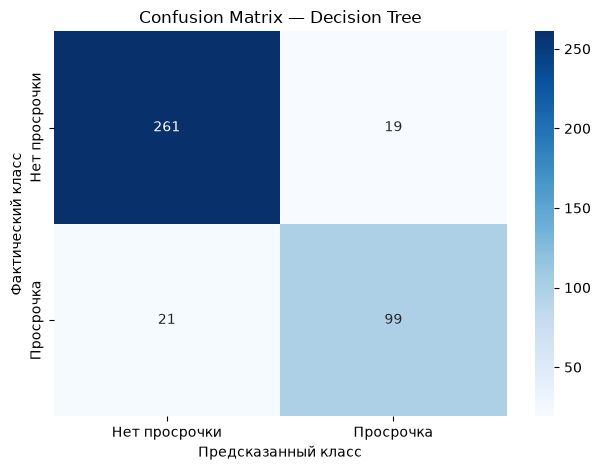

In [10]:
tree_model = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_result = train_and_evaluate(
    DecisionTreeClassifier(max_depth=6, random_state=42),
    "Decision Tree",
    X_train,
    X_test
)

Random Forest

Accuracy : 0.9275
Precision: 0.9027
Recall   : 0.8500
F1-Score : 0.8755
ROC-AUC  : 0.9748


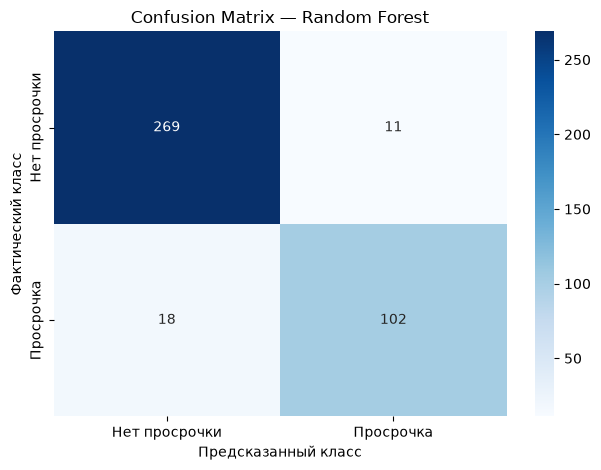

In [11]:
forest_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
forest_result = train_and_evaluate(
    forest_model,
    "Random Forest",
    X_train,
    X_test
)

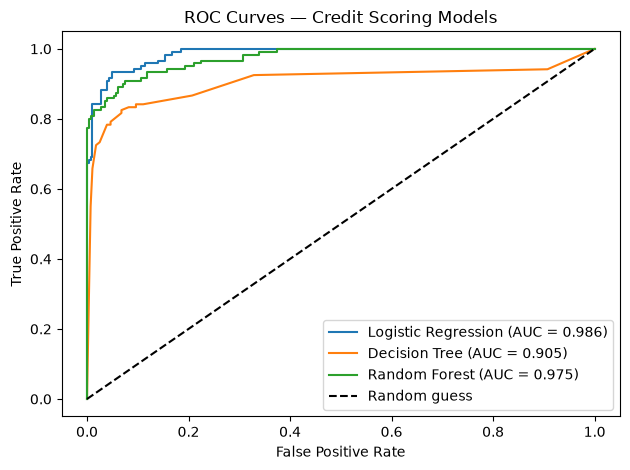

In [12]:
models_results = {
    "Logistic Regression": logistic_result,
    "Decision Tree": tree_result,
    "Random Forest": forest_result
}

for name, result in models_results.items():
    fpr, tpr, _ = roc_curve(y_test, result["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {result['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Credit Scoring Models")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
metrics = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

results_df = pd.DataFrame({
    "Logistic Regression": logistic_result,
    "Decision Tree": tree_result,
    "Random Forest": forest_result
}).T[metrics]

results_df.style.format("{:.4f}")

,accuracy,precision,recall,f1_score,roc_auc
Logistic Regression,0.9450,0.9298,0.8833,0.9060,0.9857
Decision Tree,0.9000,0.8390,0.8250,0.8319,0.9050
Random Forest,0.9275,0.9027,0.8500,0.8755,0.9748


Наилучшая модель - Logistic Regression